In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("All libraries loaded successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All libraries loaded successfully!


In [7]:
# --- UPDATE THIS PATH TO YOUR ACTUAL VALIDATION FOLDER ---
val_dir = '/content/drive/MyDrive/Colab Notebooks/SUBHAJIT_PHASE 1/Rice leaf disease Dataset original/Validation data'

# Paths to your saved models
alexnet_path = '/content/drive/MyDrive/Colab Notebooks/SUBHAJIT_PHASE 1/rice_leaf_alexnet_model.keras'
resnet_path = '/content/drive/MyDrive/Colab Notebooks/SUBHAJIT_PHASE 1/rice_disease_model (2).pth'

# Get class names
class_names = sorted(os.listdir(val_dir))
num_classes = len(class_names)
print(f"Detected {num_classes} classes: {class_names}")

Detected 8 classes: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Narrow Brown Leaf Spot', 'Rice Hispa', 'Sheath Blight']


In [8]:
print("Loading AlexNet....")

# Load validation data for TensorFlow (227x227 for AlexNet)
val_dataset_tf = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(227, 227),
    batch_size=32,
    shuffle=False # MUST BE FALSE FOR ENSEMBLING
)

# Load the saved AlexNet model
alexnet_model = tf.keras.models.load_model(alexnet_path)

# Extract True Labels from TF Dataset
y_true = np.concatenate([y for x, y in val_dataset_tf], axis=0)

# Get AlexNet Probabilities
print("Extracting AlexNet Probabilities...")
alexnet_probs = alexnet_model.predict(val_dataset_tf)
alexnet_preds = np.argmax(alexnet_probs, axis=1)

# CALCULATE ALEXNET ACCURACY
alexnet_acc = accuracy_score(y_true, alexnet_preds)

# FREE UP GPU MEMORY FOR PYTORCH
del alexnet_model
tf.keras.backend.clear_session()
print(f"AlexNet extraction complete! (Accuracy: {alexnet_acc*100:.2f}%) Memory cleared.")

Loading AlexNet....
Found 186 files belonging to 8 classes.
Extracting AlexNet Probabilities...
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 535ms/step
AlexNet extraction complete! (Accuracy: 69.35%) Memory cleared.


In [9]:
print("\n Loading ResNet-18...")
import torch
import torch.distributed as dist
import os
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import accuracy_score
import torchvision.models as models

# =====================================================================
# 📍 STEP 1: PASTE YOUR EXACT PATHS HERE
# =====================================================================

# 1. Validation Folder Path
val_dir_pytorch = '/content/drive/MyDrive/Colab Notebooks/SUBHAJIT_PHASE 1/Rice leaf disease Dataset original/Validation data'

# 2. ResNet-18 Model File Path
resnet_path_exact = '/content/drive/MyDrive/Colab Notebooks/SUBHAJIT_PHASE 1/rice_disease_model (2).pth'

# =====================================================================
# 📍 STEP 2: THE "DUMMY MULTI-GPU" TRICK (The Fix!)
# =====================================================================
if not dist.is_initialized():
    print("🔧 Initializing dummy distributed environment...")
    os.environ['MASTER_ADDR'] = 'localhost'
    os.environ['MASTER_PORT'] = '12345'
    dist.init_process_group("gloo", rank=0, world_size=1)

# =====================================================================
# 📍 STEP 3: PYTORCH DATA LOADING & INFERENCE
# =====================================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

try:
    val_dataset_pt = ImageFolder(root=val_dir_pytorch, transform=transform)
    val_loader = DataLoader(val_dataset_pt, batch_size=32, shuffle=False)
    print("Validation Data loaded successfully!")
except Exception as e:
    print(f"ERROR LOADING DATA: {e}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    # FIX: Initialize the model architecture first
    # Assuming 8 classes based on previous cell output
    resnet_model = models.resnet18(num_classes=8)

    # Load the state_dict
    checkpoint = torch.load(resnet_path_exact, map_location=device)

    # If the checkpoint is just the state_dict, load it.
    # If it's a dictionary containing 'state_dict', extract that first.
    state_dict = checkpoint.get('state_dict', checkpoint) if isinstance(checkpoint, dict) else checkpoint

    # Handle 'module.' prefix if saved with DataParallel
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k
        new_state_dict[name] = v

    resnet_model.load_state_dict(new_state_dict)
    resnet_model = resnet_model.to(device)
    resnet_model.eval()
    print("✅ ResNet-18 Model loaded successfully!")
except Exception as e:
    print(f"ERROR LOADING MODEL: {e}")

print("Extracting ResNet-18 Probabilities... Please wait ⏳")
resnet_probs_list = []
y_true_pytorch = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = resnet_model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        resnet_probs_list.append(probs.cpu().numpy())
        y_true_pytorch.extend(labels.numpy())

resnet_probs = np.vstack(resnet_probs_list)
resnet_preds = np.argmax(resnet_probs, axis=1)
y_true = np.array(y_true_pytorch)

resnet_acc = accuracy_score(y_true, resnet_preds)
print(f"🔥 Phase 2 ResNet-18 extraction complete! (Accuracy: {resnet_acc*100:.2f}%)")


 Loading ResNet-18...
Validation Data loaded successfully!
✅ ResNet-18 Model loaded successfully!
Extracting ResNet-18 Probabilities... Please wait ⏳
🔥 Phase 2 ResNet-18 extraction complete! (Accuracy: 97.31%)


In [13]:
print("\nFusing the Models (Weighted Ensemble)...")

# Define the weights (They must add up to 1.0)
weight_resnet = 0.60
weight_alexnet = 0.40

# Calculate the weighted average of the probabilities
ensemble_probs = (weight_resnet * resnet_probs) + (weight_alexnet * alexnet_probs)

# Final prediction is the class with the highest combined probability
ensemble_preds = np.argmax(ensemble_probs, axis=1)

# CALCULATE ENSEMBLE ACCURACY
ensemble_acc = accuracy_score(y_true, ensemble_preds)
print(f" FINAL ENSEMBLE ACCURACY: {ensemble_acc*100:.2f}%")


Fusing the Models (Weighted Ensemble)...
 FINAL ENSEMBLE ACCURACY: 96.24%


Accuracy Bar Chart...


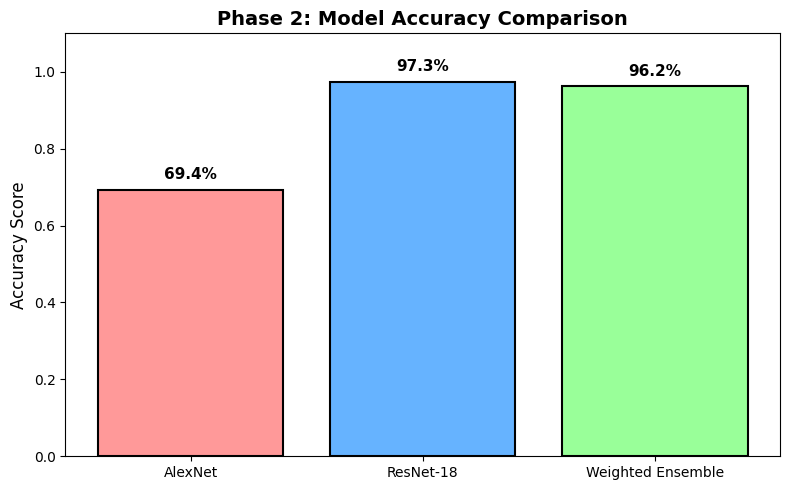

In [14]:
import matplotlib.pyplot as plt

print("Accuracy Bar Chart...")

plt.figure(figsize=(8, 5))
models = ['AlexNet', 'ResNet-18', 'Weighted Ensemble']
accuracies = [alexnet_acc, resnet_acc, ensemble_acc]

# Using professional colors
colors = ['#ff9999', '#66b3ff', '#99ff99']

# Create the bar chart
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.ylim(0, 1.1)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Phase 2: Model Accuracy Comparison', fontsize=14, fontweight='bold')

# Add the exact percentage text on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f'{yval*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import classification_report

print("Classification Report...\n")
print("="*60)
print("              ENSEMBLE CLASSIFICATION REPORT")
print("="*60)

# Generate and print the report
report = classification_report(y_true, ensemble_preds, target_names=class_names)
print(report)
print("="*60)

Classification Report...

              ENSEMBLE CLASSIFICATION REPORT
                        precision    recall  f1-score   support

 Bacterial Leaf Blight       0.95      0.90      0.92        20
            Brown Spot       1.00      0.96      0.98        27
     Healthy Rice Leaf       0.90      0.95      0.92        19
            Leaf Blast       0.97      1.00      0.98        31
            Leaf scald       1.00      1.00      1.00        23
Narrow Brown Leaf Spot       1.00      1.00      1.00        16
            Rice Hispa       0.95      0.91      0.93        22
         Sheath Blight       0.93      0.96      0.95        28

              accuracy                           0.96       186
             macro avg       0.96      0.96      0.96       186
          weighted avg       0.96      0.96      0.96       186



Confusion Matrix Heatmap...


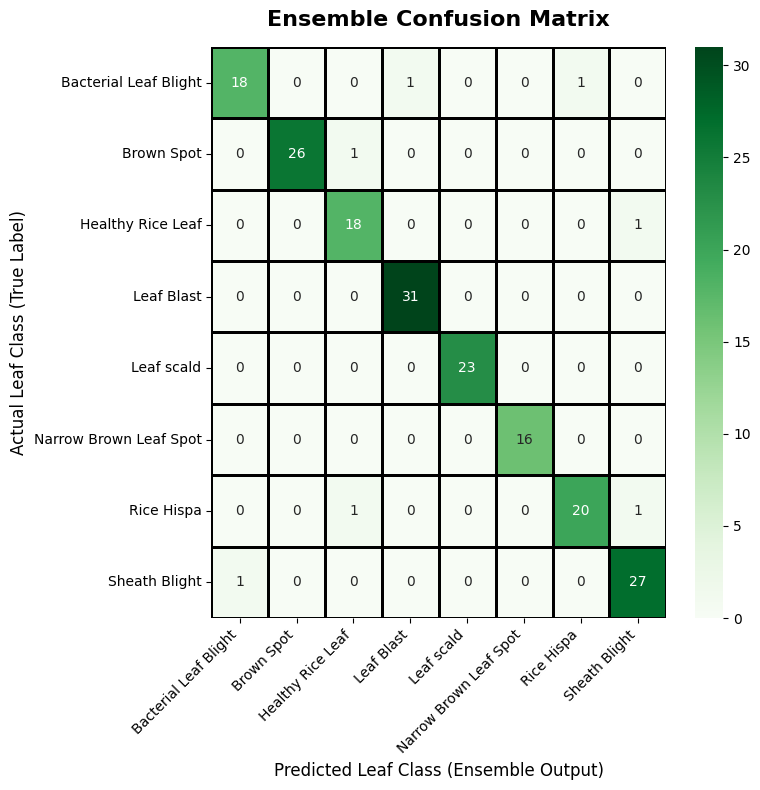

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Confusion Matrix Heatmap...")

plt.figure(figsize=(8, 8))

# Calculate the confusion matrix
cm = confusion_matrix(y_true, ensemble_preds)

# Plot it using Seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black')

plt.title('Ensemble Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Actual Leaf Class (True Label)', fontsize=12)
plt.xlabel('Predicted Leaf Class (Ensemble Output)', fontsize=12)

# Rotate the text so it is easy to read
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Multi-Class ROC Curve...


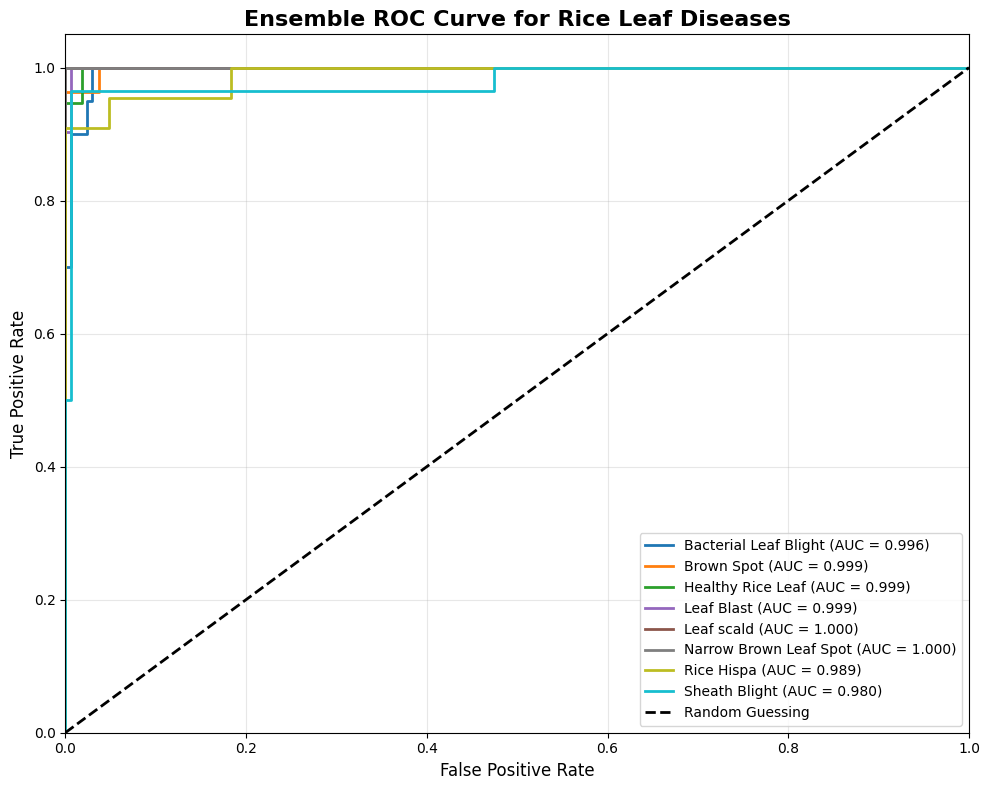

In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print("Multi-Class ROC Curve...")

# 1. Binarize the labels (Required for ROC calculation)
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(10, 8))

# 2. Calculate and plot the ROC curve for each individual class
colors = plt.cm.tab10(np.linspace(0, 1, num_classes)) # Automatically generate enough colors

for i, color in zip(range(num_classes), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], ensemble_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

# 3. Plot the standard 50/50 guessing line (The baseline)
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Guessing')

# 4. Format the graph
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Ensemble ROC Curve for Rice Leaf Diseases', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()